## Compares the jackknife errors with errors using the standard deviation

In [92]:
from scipy.stats import kde
import h5py
import astropy.io.fits as fits
import csv
import pandas as pd
import numpy as np
import tables
import pickle
import os
from astropy.table import Table
from astropy.coordinates import SkyCoord
from tqdm import tqdm
from astropy.io import ascii
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import incredible as cr
from scipy.special import erf
from scipy import stats
import scipy.optimize as opt
from scipy import stats
import scipy.optimize as opt
import emcee
import tqdm
import pickle
from astropy import table
from astropy.table import Table, join, unique
from specutils import SpectralRegion
from scipy.interpolate import BSpline, make_interp_spline, UnivariateSpline

from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d
import numpy as np
import astropy.units as u
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18
from astropy.cosmology import z_at_value
cosmo = Planck18

## Functions for computing spectroscopic richness and profiles
from projection_functions import *


##Plotting
import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt

plot_params = {

'axes.linewidth': 1.25,
'xtick.major.width': 1, 'ytick.major.width': 1,
'xtick.minor.width': 1, 'ytick.minor.width': 1,
'xtick.major.size': 12, 'ytick.major.size': 12,
'xtick.labelsize': 12, 'ytick.labelsize': 12,
'xtick.direction': 'in', 'ytick.direction': 'in',
'xtick.major.pad': 6, 'xtick.minor.pad': 6,
'figure.constrained_layout.use': True,
#'text.usetex': True,
'font.family': 'Serif',
'font.size': 14,
'legend.fontsize': 11
    
}
plt.rcParams.update(plot_params)

In [160]:
import bces.bces as BCES
from scipy.optimize import curve_fit
from scipy.stats.distributions import chi2
from scipy.odr import ODR, Model, RealData

# Define your fitting function
def loglinear_function(x, m, c):
    return m * np.log10(x) + c

# Quadratic model: y = a*x^2 + b*x + c
def logquad_function(beta, x):
    a, b, c = beta
    return a*x**2 + b*x + c

'''
Fitting using Bivariate Correlated Errors and Intrinsic Scatter (BCES). Need to take into account covariance!
'''
def linear_fit(x, y, xerr, yerr, verbose=False, bcesMethod=0):
    cov = np.zeros_like(lambda_rm_list)
    #cov = np.ones_like(lambda_rm_list)*np.cov(x,y)[1,0] # Covariance between xerr and yerr (set to zeros if uncorrelated)

    # Perform BCES regression
    a, b, aerr, berr, covab = BCES.bces(logx, logxerr, logy, logyerr, cov)
    
    # 'a' and 'b' contain the best-fit parameters (slope and intercept) for different BCES lines.
    # 'aerr' and 'berr' are their respective standard deviations.
    # 'covab' is the covariance between 'a' and 'b'.
    
    # For example, to access the OLS(Y|X) results (index 0):
    slope_ols_yx = a[bcesMethod]
    intercept_ols_yx = b[bcesMethod]
    slope_err_ols_yx = aerr[bcesMethod]
    intercept_err_ols_yx = berr[bcesMethod]
    covab = covab[bcesMethod]

    if verbose:
        print(f"OLS(Y|X) Slope: {slope_ols_yx:.2f} +/- {slope_err_ols_yx:.2f}")
        print(f"OLS(Y|X) Intercept: {intercept_ols_yx:.2f} +/- {intercept_err_ols_yx:.2f}")

    return  slope_ols_yx, intercept_ols_yx, slope_err_ols_yx, intercept_err_ols_yx, covab

'''
Compute chi-sq for stacked clusters. For correlated errors on x and y for linear fit.
'''
def compute_chisq_linear(p_cl_bin, x, y, xerr, yerr, slope, intercept, cov=True, verbose=False):
    # Calculate the effective variance for each point with covariance
                                   
    df_dx_at_x = slope #Derivative at each x_data point 
    #df_dx_at_x = 10**intercept *(slope)*x**(slope-1)

    ##Not considering the covariance of x,y the effective variance is given by: https://www.roma1.infn.it/~dagos/lfit/node4.html
    if cov:
        effective_variance = (y**2 + (df_dx_at_x * xerr)**2) + np.ones_like(xerr)*2*np.cov(x,y)[1,0]
    else:
        effective_variance = (yerr**2 + (df_dx_at_x * xerr)**2)
    
    # Calculate the chi-squared statistic
    #y_fitted = np.log10(10**intercept * x**slope)
    y_fitted = slope*x + intercept
    chi_squared = np.sum(p_cl_bin*(y - y_fitted)**2 /effective_variance)
    
    # Degrees of freedom (N - number of parameters)
    n = len(x) #Number of data points
    k = 2 #number of parameters
    degrees_of_freedom = len(x) - k
    p_value = chi2.sf(chi_squared, degrees_of_freedom)

    ##BIC 
    BIC = chi_squared + k * np.log(n)

    if verbose:
        print(f"Chi-squared statistic: {chi_squared:.3f}")
        print(f"Degrees of freedom: {degrees_of_freedom}")
        print(f"P-value using sf: {p_value}")
        print(f"Covariance is:  {np.cov(x,y)[1,0]}")
        print(f"Variance is: {(yerr**2 + (df_dx_at_x * xerr)**2)}")
        print(f"BIC is:  {BIC}")

    
    return chi_squared, degrees_of_freedom, p_value


'''
Compute chi-sq for stacked clusters.  Quadratic model: y = a*x^2 + b*x + c
'''
def compute_chisq_quad(p_cl_bin, x, y, xerr, yerr, a, b, c, cov=True, verbose=False):
    # Calculate the effective variance for each point with covariance
                                   
    df_dx_at_x = 2*a*x + b #Derivative at each x_data point 
    #df_dx_at_x = 10**intercept *(slope)*x**(slope-1)

    ##Not considering the covariance of x,y the effective variance is given by: https://www.roma1.infn.it/~dagos/lfit/node4.html
    if cov:
        effective_variance = (y**2 + (df_dx_at_x * xerr)**2) + np.ones_like(xerr)*2*np.cov(x,y)[1,0]
    else:
        effective_variance = (yerr**2 + (df_dx_at_x * xerr)**2)
    
    # Calculate the chi-squared statistic
    #y_fitted = np.log10(10**intercept * x**slope)
    y_fitted = a*x**2 + b*x + c
    chi_squared = np.sum(p_cl_bin*(y - y_fitted)**2 /effective_variance)
    
    # Degrees of freedom (N - number of parameters)
    n = len(x) #Number of data points
    k = 3 #number of parameters
    degrees_of_freedom = len(x) - k
    p_value = chi2.sf(chi_squared, degrees_of_freedom)

    ##BIC 
    BIC = chi_squared + k * np.log(n)

    if verbose:
        print(f"Chi-squared statistic: {chi_squared:.3f}")
        print(f"Degrees of freedom: {degrees_of_freedom}")
        print(f"P-value using sf: {p_value}")
        print(f"Covariance is:  {np.cov(x,y)[1,0]}")
        print(f"Variance is: {(yerr**2 + (df_dx_at_x * xerr)**2)}")
        print(f"BIC is:  {BIC}")
    
    return chi_squared, degrees_of_freedom, p_value
    

def loglike_gaussian_diag_noconst(data, model, sigma):
    resid = data - model
    return -0.5 * np.sum((resid/sigma)**2)

In [94]:
with open('bgs_clus_RM_gal_matched.pickle', 'rb') as handle:
    bgs_matched = pickle.load(handle)

fcols = ['g','r','z','w1','w2']
for col in fcols:
    #bgs_matched['flux_'+col.lower()+'_dered'] = bgs_matched['FLUX_'+col]/data['MW_TRANSMISSION_'+col]
    bgs_matched['r_dered'] = 22.5 - 2.5*np.log10(bgs_matched['flux_r_dered'])
    bgs_matched['g_dered'] = 22.5 - 2.5*np.log10(bgs_matched['flux_g_dered'])
    bgs_matched['gmr'] = bgs_matched['g_dered']-bgs_matched['r_dered']

#binGap = 1e-5
wide_bin_1 = np.linspace(-0.1,-0.005,21, endpoint=False)
small_bin = np.linspace(-0.005,0.005,21, endpoint=False)
micro_bin = np.linspace(-0.005,0.005,31)
wide_bin_2 = np.linspace(0.005,0.1,21, endpoint=False)


binBoundaries = np.hstack((wide_bin_1, small_bin))
binBoundaries = np.hstack((binBoundaries, wide_bin_2))
binCent = np.asarray([(binBoundaries[i] + binBoundaries[i+1])/2 for i in range(len(binBoundaries)-1)])
binCent_micro = np.asarray([(micro_bin[i] + micro_bin[i+1])/2 for i in range(len(micro_bin)-1)])
bin_width = np.asarray([binBoundaries[i+1]-binBoundaries[i] for i in range(len(binBoundaries[:-1]))])

## None overlapping bins
assert len(set(binCent)) == len(binCent), "Overlapping bins"
assert len(set(binBoundaries)) == len(binBoundaries), "Overlapping bins"

In [120]:
## Bin by redshift
z_bins = [[0.1,0.2],[0.2,0.3],[0.3,0.4]]

lmda_bin_edges = np.logspace(np.log10(20), np.log10(120), 12)
lmda_bins = [[lmda_bin_edges[i], lmda_bin_edges[i+1]] for i in range(len(lmda_bin_edges)-1)]

##Create an absolute magnitude column
cosmo = Planck18
h = 0.67
M_r = bgs_matched['r_dered']-cosmo.distmod(bgs_matched['Z_BGS']).value - 5*np.log10(h)
bgs_matched['M_r'] = M_r ##comoving M with h-scaling

##Cuts
bgs_matched = bgs_matched[np.where(bgs_matched['r_dered'] < 19.5)]

In [121]:
#Assigning spectrospic richnesses to individual cluster. 

from scipy.stats import gaussian_kde
import matplotlib.colors as colors

rmTable = unique(bgs_matched, keys='ID')
ID_list, lambda_tot_list, lambda_true_list  = calc_specRichness_individual(binBoundaries, binCent, bgs_matched)
lambda_rm = [rm_lambda for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list] 
rm_id = [rmTable['ID'][i] for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list] 
ind = [i for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list]

lambda_tot_list = np.asarray(lambda_tot_list)
lambda_true_list = np.asarray(lambda_true_list)
lambda_rm = np.asarray(lambda_rm)

##Filtering out the clusters with no spectrospic richness information and assigning spectroscopic information
rmTable = rmTable[ind]
rmTable['lambda_true'] = lambda_true_list
rmTable['lambda_tot'] = lambda_tot_list
rm_df = rmTable.to_pandas()

## Group df by lmba_bins
# Create a binned column
rm_df['lmda_bin'] = pd.cut(rm_df['LAMBDA'], lmda_bin_edges)

## Jackknife vs Standard Deviation Errors

In [122]:
from astropy.stats import jackknife_stats as jk_stats
from scipy.stats import sem

for i, lmda_bin in enumerate(lmda_bins):
   cut = (bgs_matched['LAMBDA'] >= lmda_bin[0]) & (bgs_matched['LAMBDA'] < lmda_bin[1])  
   bgs_cur = bgs_matched[cut]

   ##Filtering out individual clusters
   rmTable = unique(bgs_cur, keys='ID')
   ID_list, lambda_tot_list, lambda_true_list  = calc_specRichness_individual(binBoundaries, binCent, bgs_cur)
   lambda_rm = [rm_lambda for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list] 
   rm_id = [rmTable['ID'][i] for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list] 
   ind = [i for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list]
   lambda_tot_list = np.asarray(lambda_tot_list)
   lambda_true_list = np.asarray(lambda_true_list)
   lambda_rm = np.asarray(lambda_rm)

   ##Filtering out the clusters with no spectrospic richness information and assigning spectroscopic information
   rmTable = rmTable[ind]
   rmTable['lambda_true'] = lambda_true_list
   rmTable['lambda_tot'] = lambda_tot_list
      
   ##Individual 
   lambda_true_err_jk, bias, std_err, _ = jk_stats(rmTable['lambda_true'], sem, confidence_level=0.68)
   print('Individual: ', np.mean(rmTable['lambda_tot']), np.mean(rmTable['lambda_true']), lambda_true_err_jk)
   
   ##stacked analysis
   lambda_tot_stacked, lambda_true_stacked, lambda_true_err = calc_specRichness_stacked(binBoundaries, binCent, bgs_cur)
   print('Stacked: ', lambda_tot_stacked, lambda_true_stacked, lambda_true_err)


/global/common/software/desc-cl/zzhang13/conda/myDESC/lib/python3.9/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/global/common/software/desc-cl/zzhang13/conda/myDESC/lib/python3.9/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


Individual:  42.692521319062664 21.20659725940606 0.3102965144773415
Stacked:  41.857309734517166 20.78477581372435 1.4826666975271319
Individual:  44.089249663083926 23.258650081468087 0.3723359937511813
Stacked:  43.23863353221661 22.795288276735977 1.4958219378194033
Individual:  43.26161040515398 22.665312379714074 0.4499392561401595
Stacked:  42.44410049189949 22.248953092953542 1.6426248810470334
Individual:  48.14029642343311 27.29029707683593 0.5904437887753617
Stacked:  47.159406417691436 26.726477072925253 1.7659236399225955
Individual:  56.54938937271036 31.798882825106702 0.9434058220709605
Stacked:  55.450525061852204 31.155021831764206 2.1618298424045195
Individual:  51.7034064070465 32.16827787314389 0.8989347676008079
Stacked:  51.25846809025499 31.879956135013458 2.2629793141022247
Individual:  60.29542299333021 40.569095017390616 1.817153459240973
Stacked:  58.852648374113464 39.601032512178925 2.5958640436692257
Individual:  64.16088327952673 45.98960261842994 2.2757

In [123]:
### Plotting params
smoothing_param = 0
xlim_inset_low = -0.005; xlim_inset_high = 0.005
xlim_low = -0.1; xlim_high = 0.1
ylim_low = 1; ylim_high = 1e4
ylim_inset_low = 10; ylim_inset_high = 1e4
z_anchor = 0.4
shift_wide_val = 0.0002
shift_small_val = 0.0001
fontsize=14
alpha=0.5

In [124]:
MagDict = {
           #r'$ M_r < -19.8$': np.asarray((bgs_matched['M_r'] <-19.8)), \
           r'$ M_r < -20.99, $': np.asarray((bgs_matched['M_r'] <-20.99)), \
           r'$ M_r < -21.5, $': np.asarray((bgs_matched['M_r'] <-21.5)), 
          }

zDict = {
           r'$z \in [0.10,0.33)$':np.asarray((bgs_matched['Z_SPEC_x'] >= 0.10) & (bgs_matched['Z_SPEC_x'] < 0.33)), \
           #r'$z \in [0.20,0.30)$':np.asarray((bgs_matched['Z_SPEC_x'] >= 0.20) & (bgs_matched['Z_SPEC_x'] < 0.30)), \
           r'$z \in [0.33,0.40)$':np.asarray((bgs_matched['Z_SPEC_x'] >= 0.33) & (bgs_matched['Z_SPEC_x'] < 0.40))
          }

#fmtList = ['h', 'o', 'D', '*']
#MagDict = [ {k1:MagDict[k1], 'fmt':k2} for k1, k2 in zip(MagDict, fmtList)]

In [125]:
MagDict = {
           #r'$ M_r < -19.8$': np.asarray((bgs_matched['M_r'] <-19.8)), \
           r'$ M_r < -20.99, $': np.asarray((bgs_matched['M_r'] <-20.99)), \
           r'$ M_r < -21.5, $': np.asarray((bgs_matched['M_r'] <-21.5)), 
          }

zDict = {
           r'$z \in [0.10,0.33)$':np.asarray((bgs_matched['Z_SPEC_x'] >= 0.10) & (bgs_matched['Z_SPEC_x'] < 0.33)), \
           #r'$z \in [0.20,0.30)$':np.asarray((bgs_matched['Z_SPEC_x'] >= 0.20) & (bgs_matched['Z_SPEC_x'] < 0.30)), \
           r'$z \in [0.33,0.40)$':np.asarray((bgs_matched['Z_SPEC_x'] >= 0.33) & (bgs_matched['Z_SPEC_x'] < 0.40))
          }

#fmtList = ['h', 'o', 'D', '*']
#MagDict = [ {k1:MagDict[k1], 'fmt':k2} for k1, k2 in zip(MagDict, fmtList)]

In [126]:
##Valid indices -- see table
validInd = [[0,0],[1,1]]

combinedDict = {}
for i, (key1, val1) in enumerate(MagDict.items()):
    for j, (key2, val2) in enumerate(zDict.items()):
        if any([i,j] == sublist for sublist in validInd):
            name = key1 + ' ' + key2
            val = val1 & val2 ##Boolean logic
            combinedDict[name] = val

        else:
            continue

$ M_r < -20.99, $ $z \in [0.10,0.33)$
Chi-squared statistic: 4.060
Degrees of freedom: 9
P-value using sf: 0.907401652435093
Covariance is:  0.04953324767300633
Variance is: [0.00415279 0.00436322 0.00467072 0.00349373 0.00405619 0.00367268
 0.00377548 0.0035657  0.00338226 0.00364197 0.00276333]
$\log(y)=0.91(\pm 0.07)\log(x) +0.16(\pm 0.11), p=0.907$
$ M_r < -21.5, $ $z \in [0.33,0.40)$
Chi-squared statistic: 1.448
Degrees of freedom: 9
P-value using sf: 0.9975114752520605
Covariance is:  0.03439167969222484
Variance is: [0.01371057 0.01445391 0.01418109 0.01322646 0.01905252 0.01582331
 0.01028484 0.01572862 0.01321667 0.0146012  0.01366482]
$\log(y)=0.63(\pm 0.05)\log(x) +0.65(\pm 0.09), p=0.998$


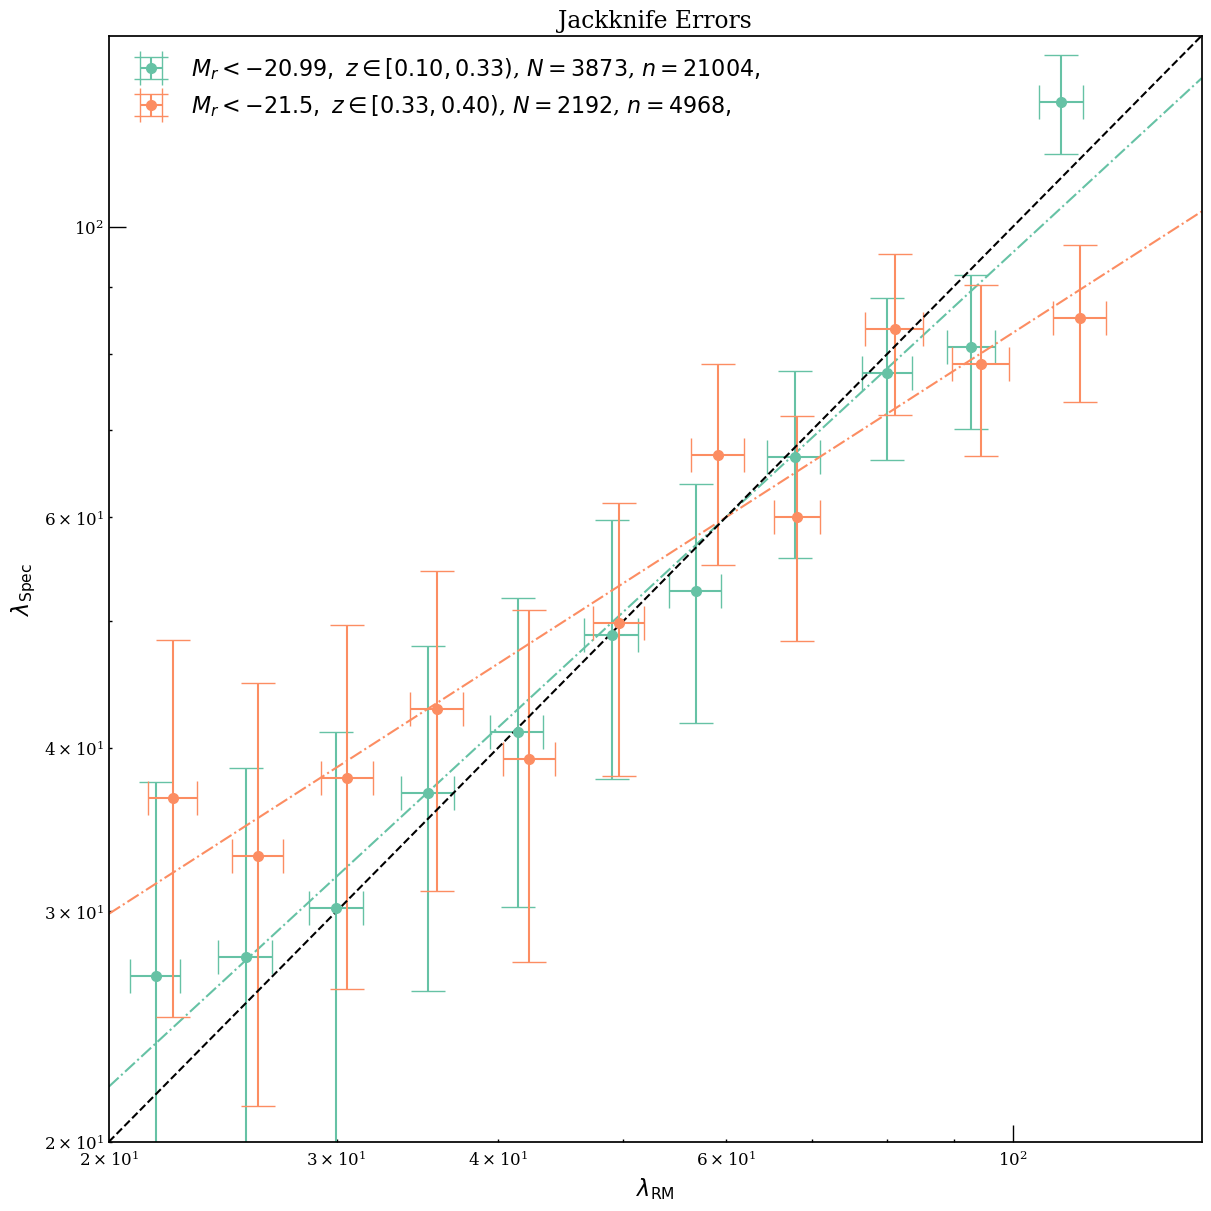

In [127]:
from scipy import stats

fig, ax = plt.subplots(figsize=(12,12))
xlow = 20; xhigh = 140
xline = np.linspace(xlow, xhigh,1000)
cmap = plt.get_cmap('Set2')
color_ind = 0
fontsize=16

xshift = 1
for key, val in combinedDict.items():
    print(key)
    cutTable = bgs_matched[val]
    numTotal = len(cutTable)
    numCluster = len(np.unique(cutTable['ID']))

    lambda_true_list = []
    lambda_rm_list = []
    lambda_rm_stddev_list = []
    lambda_true_stddev_list = []
    lambda_rm_sem_list = []
    lambda_true_sem_list = []
    for i, lmda_bin in enumerate(lmda_bins):
        cut = (cutTable['LAMBDA'] >= lmda_bin[0]) & (cutTable['LAMBDA'] < lmda_bin[1])
            
        binnedTable = cutTable[cut]
        lambda_tot, lambda_true, lambda_true_err = calc_specRichness_stacked(binBoundaries, binCent, binnedTable)

        ##Stacked clusters
        numCl = len(unique(binnedTable, keys='ID'))
        lambda_rm_list = np.hstack((lambda_rm_list, np.mean(binnedTable['LAMBDA'])))  
        lambda_rm_stddev_list = np.hstack((lambda_rm_stddev_list, np.std(binnedTable['LAMBDA']))) 
        lambda_rm_sem_list = np.hstack((lambda_rm_sem_list, stats.sem(binnedTable['LAMBDA'])))  
        lambda_true_stddev_list = np.hstack((lambda_true_stddev_list, lambda_true_err))
        lambda_true_sem_list = np.hstack((lambda_true_sem_list, lambda_true_err/np.sqrt(numCl)))
        lambda_true_list = np.hstack((lambda_true_list,lambda_true))   

        ##Calculating individual richnesses and using jackknife error
        rmTable = unique(binnedTable, keys='ID')
        ID_list, lambda_tot_list_ind, lambda_true_list_ind  = calc_specRichness_individual(binBoundaries, binCent, binnedTable)
        lambda_rm = [rm_lambda for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list] 
        rm_id = [rmTable['ID'][i] for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list] 
        ind = [i for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list]
        lambda_tot_list_ind = np.asarray(lambda_tot_list_ind)
        lambda_true_list_ind = np.asarray(lambda_true_list_ind)
        lambda_rm = np.asarray(lambda_rm)
    
        ##Filtering out the clusters with no spectrospic richness information and assigning spectroscopic information
        rmTable = rmTable[ind]
        rmTable['lambda_true'] = lambda_true_list_ind
        rmTable['lambda_tot'] = lambda_tot_list_ind
        lambda_true_err_jk, bias, std_err, _ = jk_stats(rmTable['lambda_true'], sem, confidence_level=0.68)

    ##Linear fitting
    bcesMethod=0
    logx = np.log10(lambda_rm_list)
    logy = np.log10(lambda_true_list)
    logxerr = lambda_rm_sem_list/(lambda_rm_list*np.log(10))
    logyerr = lambda_true_sem_list/(lambda_true_list*np.log(10))
    ##Use the standard error for errors on the coefficients. 
    slope, intercept, slope_err, intercept_err, covab = linear_fit(lambda_rm_list, lambda_true_list, lambda_rm_sem_list, lambda_true_sem_list, bcesMethod=bcesMethod)

    ##Use the standard error of the regression (approx. standard deviation) for goodness of fit.
    chi_squared, degrees_of_freedom, p_value = compute_chisq(lambda_rm_list, lambda_true_list, lambda_rm_stddev_list, lambda_true_stddev_list, slope, intercept, \
                                                             cov=False, verbose=True)
    best_fit_label = r'$\log(y)={:.2f}(\pm {:.2f})\log(x) {:+.2f}(\pm {:.2f}), p={:.3f}$'.format(slope, slope_err, intercept, intercept_err, p_value)
    label = key + ', ' + r'$N={:d}$'.format(numCluster) + r', $n={:d}$'.format(numTotal) + ', ' + best_fit_label

    ##Set pivot point to 60
    bias = np.log10(60)*(1-slope)-intercept
    intercept += bias
    y_fitted = 10**intercept * xline**slope
    ax.plot(xline, y_fitted, linestyle='-.', color=cmap(color_ind))
    best_fit_label = r'$\log(y)={:.2f}(\pm {:.2f})\log(x) {:+.2f}(\pm {:.2f}), p={:.3f}$'.format(slope, slope_err, intercept, intercept_err, p_value)
    label = key + ', ' + r'$N={:d}$'.format(numCluster) + r', $n={:d},$'.format(numTotal) ## + '\n ' + best_fit_label + '\n'

    print(best_fit_label)
    ##After setting the pivot point both the values and the errors in linear scale are multiplied by a factor of 10**bias. 
    ax.errorbar(lambda_rm_list*xshift, lambda_true_list*10**bias, xerr = lambda_rm_stddev_list, yerr = lambda_true_err_jk*10**bias, \
                linestyle='none', label=label, capsize=12, ms=7, color=cmap(color_ind), fmt='o')

    #covm=np.array([ (slope_err[bcesMethod]**2,covab[bcesMethod]), (covab[bcesMethod], intercept_err[bcesMethod]**2) ])	
    # Gets lower and upper bounds on the confidence band 
    #lcb,ucb,xcb=nmmn.stats.confbandnl(xline,y_fitted,func,fitm,covm,2,0.954,x)
    #print((lambda_true_list*10**bias-y_fitted)/lambda_true_stddev_list)

    xshift *= 1.02
    color_ind +=1

ax.plot(xline,xline,color='black', linestyle='dashed')   
ax.set_xlabel(r'$\lambda_{\rm RM}$', fontsize=fontsize)
ax.set_ylabel(r'$\lambda_{\rm Spec}$', fontsize=fontsize)

ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_xticks([20,30,50,70,100,150])
ax.set_yticks([5,10,20,30,50,100,300])
ax.set_xscale('log'); 
ax.set_yscale('log')
ax.set_xlim([xlow, xhigh]); 
ax.set_ylim([xlow, xhigh])
plt.legend(frameon=False, loc='best', fontsize=fontsize)
plt.title('Jackknife Errors')
#plt.savefig('plots/lambda_spec_lambda_rm_binned_lmda_gtr20_bivariate_jackkknife_error.jpeg')
plt.show()

## Do a Quadratic Fit 

* Recalibrate the bias here. 
* Compare the BIC of quadratic function with linear.


$ M_r < -20.99, $ $z \in [0.10,0.33)$
$ M_r < -21.5, $ $z \in [0.33,0.40)$


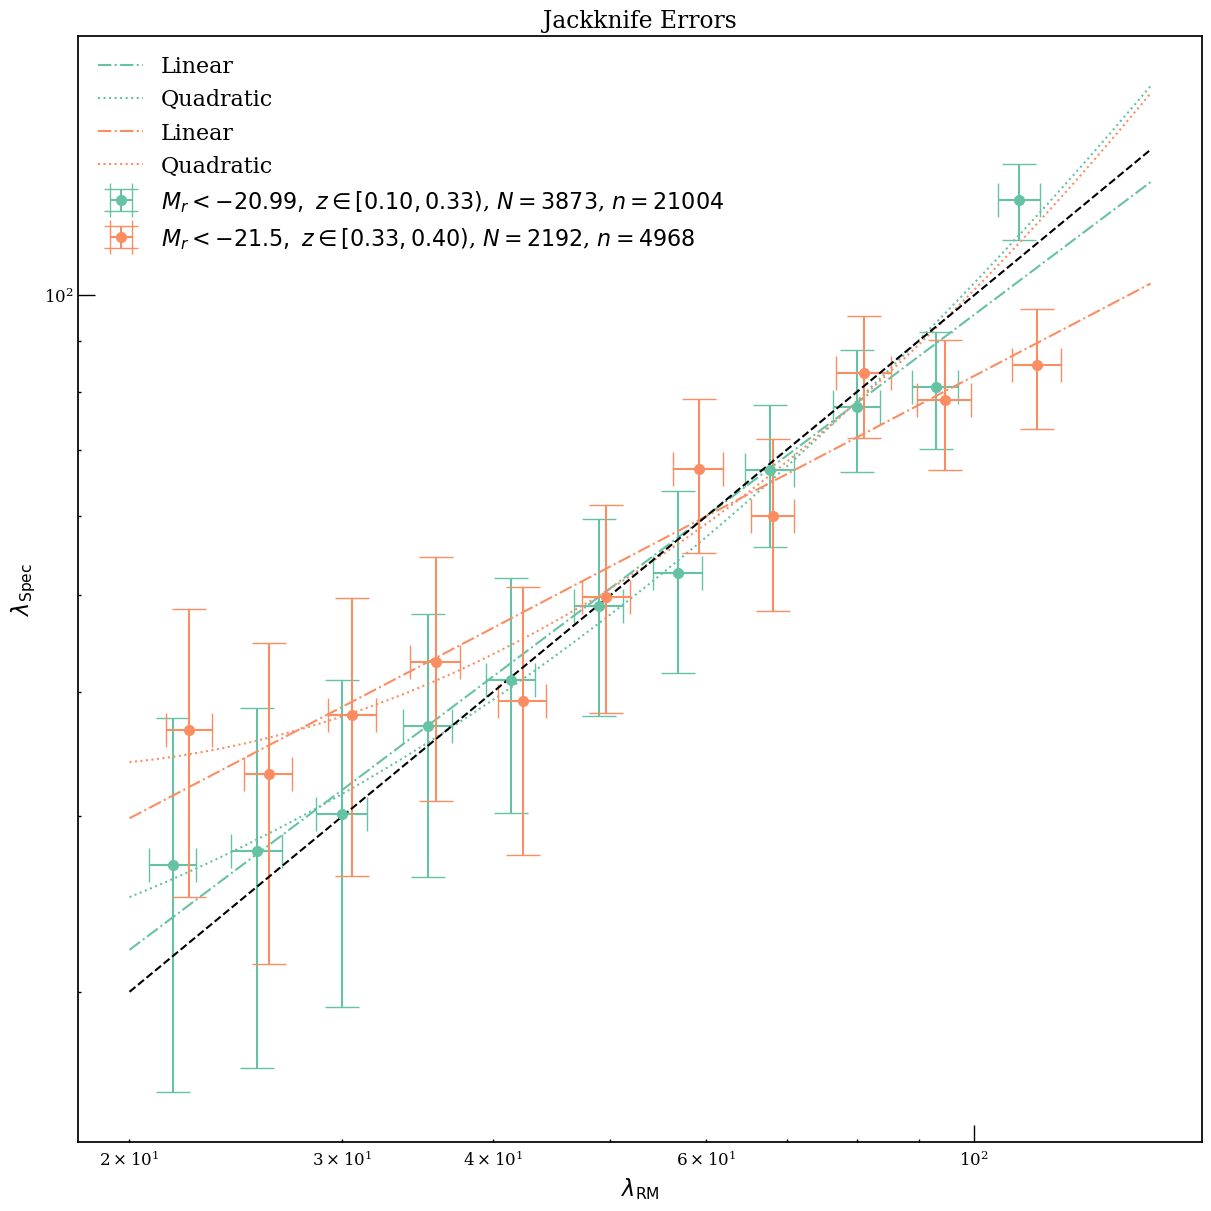

In [162]:
from scipy import stats

fig, ax = plt.subplots(figsize=(12,12))
xlow = 20; xhigh = 140
xline = np.linspace(xlow, xhigh,1000)
cmap = plt.get_cmap('Set2')
color_ind = 0
fontsize=16

xshift = 1
for key, val in combinedDict.items():
    print(key)
    cutTable = bgs_matched[val]
    numTotal = len(cutTable)
    numCluster = len(np.unique(cutTable['ID']))

    lambda_true_list = []
    lambda_rm_list = []
    lambda_rm_stddev_list = []
    lambda_true_stddev_list = []
    lambda_rm_sem_list = []
    lambda_true_sem_list = []
    for i, lmda_bin in enumerate(lmda_bins):
        cut = (cutTable['LAMBDA'] >= lmda_bin[0]) & (cutTable['LAMBDA'] < lmda_bin[1])
            
        binnedTable = cutTable[cut]
        lambda_tot, lambda_true, lambda_true_err = calc_specRichness_stacked(binBoundaries, binCent, binnedTable)

        ##Stacked clusters
        numCl = len(unique(binnedTable, keys='ID'))
        lambda_rm_list = np.hstack((lambda_rm_list, np.mean(binnedTable['LAMBDA'])))  
        lambda_rm_stddev_list = np.hstack((lambda_rm_stddev_list, np.std(binnedTable['LAMBDA']))) 
        lambda_rm_sem_list = np.hstack((lambda_rm_sem_list, stats.sem(binnedTable['LAMBDA'])))  
        lambda_true_stddev_list = np.hstack((lambda_true_stddev_list, lambda_true_err))
        lambda_true_sem_list = np.hstack((lambda_true_sem_list, lambda_true_err/np.sqrt(numCl)))
        lambda_true_list = np.hstack((lambda_true_list,lambda_true))   

        ##Calculating individual richnesses and using jackknife error
        rmTable = unique(binnedTable, keys='ID')
        ID_list, lambda_tot_list_ind, lambda_true_list_ind  = calc_specRichness_individual(binBoundaries, binCent, binnedTable)
        lambda_rm = [rm_lambda for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list] 
        rm_id = [rmTable['ID'][i] for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list] 
        ind = [i for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list]
        lambda_tot_list_ind = np.asarray(lambda_tot_list_ind)
        lambda_true_list_ind = np.asarray(lambda_true_list_ind)
        lambda_rm = np.asarray(lambda_rm)
    
        ##Filtering out the clusters with no spectrospic richness information and assigning spectroscopic information
        rmTable = rmTable[ind]
        rmTable['lambda_true'] = lambda_true_list_ind
        rmTable['lambda_tot'] = lambda_tot_list_ind
        lambda_true_err_jk, bias, std_err, _ = jk_stats(rmTable['lambda_true'], sem, confidence_level=0.68)

    ##converting variables
    x = lambda_rm_list
    y = lambda_true_list
    xerr = lambda_rm_stddev_list
    yerr = lambda_true_err_jk
    logx = np.log10(lambda_rm_list)
    logy = np.log10(lambda_true_list)
    logx_std = xerr/(x*np.log(10))
    logy_std = yerr/(y*np.log(10))
    logx_sem = lambda_rm_sem_list/(lambda_rm_list*np.log(10))
    logy_sem = lambda_true_sem_list/(lambda_true_list*np.log(10))

    ##Linear fit
    bcesMethod=0
    slope, intercept, slope_err, intercept_err, covab = linear_fit(x, y, logx_sem, logy_sem, bcesMethod=bcesMethod)
    chi_squared, degrees_of_freedom, p_value = compute_chisq(logx, logy, logx_std, logy_std, slope, intercept, \
                                                             cov=False, verbose=False)

    y_fitted_linear = 10**intercept * xline**slope

    ##Quadratic fit
    model = Model(logquad_function)
    data = RealData(logx, logy, sx=logxerr, sy=logyerr)
    beta0 = [1.0, 1.0, 1.0] #Initial guess for parameters (a, b, c)
    odr = ODR(data, model, beta0=beta0)
    out = odr.run()
    a, b, c = out.beta
    a_err, b_err, c_err = out.sd_beta #Parameter uncertainties (1σ)
    logy_fit_quad = logquad_function(out.beta, np.log10(xline))
    y_fitted_quad = 10**logy_fit_quad

    ##Set pivot point to 60 and just the intercepts and scatter accordingly
    bias = np.log10(60)*(1-slope)-intercept
    y *= 10**bias
    yerr *= 10**bias
    y_fitted_linear *= 10**bias
    y_fitted_quad *= 10**bias

    ##Trendlines
    ax.plot(xline, y_fitted_linear, linestyle='-.', color=cmap(color_ind), label = 'Linear')
    ax.plot(xline, y_fitted_quad, linestyle='dotted', color=cmap(color_ind), label ='Quadratic')
    best_fit_label = r'$\log(y)={:.2f}(\pm {:.2f})\log(x) {:+.2f}(\pm {:.2f}), p={:.3f}$'.format(slope, slope_err, intercept, intercept_err, p_value)
    label = key + ', ' + r'$N={:d}$'.format(numCluster) + r', $n={:d},$'.format(numTotal) ## + '\n ' + best_fit_label + '\n'


    ##Data measurements with errors
    label = key + ', ' + r'$N={:d}$'.format(numCluster) + r', $n={:d}$'.format(numTotal)
    ax.errorbar(x*xshift, y, xerr = xerr, yerr = yerr, \
                linestyle='none', label=label, capsize=12, ms=7, color=cmap(color_ind), fmt='o')

    xshift *= 1.02
    color_ind +=1

ax.plot(xline,xline,color='black', linestyle='dashed')   
ax.set_xlabel(r'$\lambda_{\rm RM}$', fontsize=fontsize)
ax.set_ylabel(r'$\lambda_{\rm Spec}$', fontsize=fontsize)

ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
#ax.set_xticks([20,30,50,70,100,150])
#ax.set_yticks([5,10,20,30,50,100,300])
ax.set_xscale('log'); 
ax.set_yscale('log')
#ax.set_xlim([xlow, xhigh]); 
#ax.set_ylim([xlow, xhigh])
plt.legend(frameon=False, loc='best', fontsize=fontsize)
plt.title('Jackknife Errors')
#plt.savefig('plots/lambda_spec_lambda_rm_binned_lmda_gtr20_bivariate_jackkknife_error.jpeg')
plt.show()

### Comparing the goodness of fit and BIC values for linear and quadratic

In [161]:
from scipy import stats

for key, val in combinedDict.items():
    cutTable = bgs_matched[val]
    numTotal = len(cutTable)
    numCluster = len(np.unique(cutTable['ID']))

    p_cl_bin = []
    lambda_true_list = []
    lambda_rm_list = []
    lambda_rm_stddev_list = []
    lambda_true_stddev_list = []
    lambda_rm_sem_list = []
    lambda_true_sem_list = []
    for i, lmda_bin in enumerate(lmda_bins):
        cut = (cutTable['LAMBDA'] >= lmda_bin[0]) & (cutTable['LAMBDA'] < lmda_bin[1])
        binnedTable = cutTable[cut]
        
        lambda_tot, lambda_true, lambda_true_err = calc_specRichness_stacked(binBoundaries, binCent, binnedTable)

        ##Stacked clusters
        numCl_bin = len(unique(binnedTable, keys='ID'))
        p_cl_bin = np.hstack((p_cl_bin, numCl_bin/numCluster))
        lambda_rm_list = np.hstack((lambda_rm_list, np.mean(binnedTable['LAMBDA'])))  
        lambda_rm_stddev_list = np.hstack((lambda_rm_stddev_list, np.std(binnedTable['LAMBDA']))) 
        lambda_rm_sem_list = np.hstack((lambda_rm_sem_list, stats.sem(binnedTable['LAMBDA'])))  
        lambda_true_stddev_list = np.hstack((lambda_true_stddev_list, lambda_true_err))
        lambda_true_sem_list = np.hstack((lambda_true_sem_list, lambda_true_err/np.sqrt(numCl)))
        lambda_true_list = np.hstack((lambda_true_list,lambda_true))   

        ##Calculating individual richnesses and using jackknife error
        rmTable = unique(binnedTable, keys='ID')
        ID_list, lambda_tot_list_ind, lambda_true_list_ind  = calc_specRichness_individual(binBoundaries, binCent, binnedTable)
        lambda_rm = [rm_lambda for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list] 
        rm_id = [rmTable['ID'][i] for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list] 
        ind = [i for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list]
        lambda_tot_list_ind = np.asarray(lambda_tot_list_ind)
        lambda_true_list_ind = np.asarray(lambda_true_list_ind)
        lambda_rm = np.asarray(lambda_rm)
    
        ##Filtering out the clusters with no spectrospic richness information and assigning spectroscopic information
        rmTable = rmTable[ind]
        rmTable['lambda_true'] = lambda_true_list_ind
        rmTable['lambda_tot'] = lambda_tot_list_ind
        lambda_true_err_jk, bias, std_err, _ = jk_stats(rmTable['lambda_true'], sem, confidence_level=0.68)

    ##converting variables
    p_cl_bin = np.asarray(p_cl_bin)
    x = lambda_rm_list
    y = lambda_true_list
    xerr = lambda_rm_stddev_list
    yerr = lambda_true_err_jk
    logx = np.log10(lambda_rm_list)
    logy = np.log10(lambda_true_list)
    logx_std = xerr/(x*np.log(10))
    logy_std = yerr/(y*np.log(10))
    logx_sem = lambda_rm_sem_list/(lambda_rm_list*np.log(10))
    logy_sem = lambda_true_sem_list/(lambda_true_list*np.log(10))

    ##Linear fit
    bcesMethod=0
    slope, intercept, slope_err, intercept_err, covab = linear_fit(x, y, logx_sem, logy_sem, bcesMethod=bcesMethod)
    chi_squared, degrees_of_freedom, p_value = compute_chisq(logx, logy, logx_std, logy_std, slope, intercept, \
                                                             cov=False, verbose=False)
    y_fitted_linear = 10**intercept * xline**slope

    ##Quadratic fit
    model = Model(logquad_function)
    data = RealData(logx, logy, sx=logx_sem, sy=logy_sem)
    beta0 = [1.0, -1, 1.0] #Initial guess for parameters (a, b, c)
    odr = ODR(data, model, beta0=beta0)
    out = odr.run()
    a, b, c = out.beta
    a_err, b_err, c_err = out.sd_beta #Parameter uncertainties (1σ)
    logy_fit_quad = logquad_function(out.beta, np.log10(xline))
    y_fitted_quad = 10**logy_fit_quad

    ##Likelihood
    print(p_cl_bin)
    p_cl_bin = np.ones_like(logx)
    compute_chisq_linear(p_cl_bin, logx, logy, logx_std, logy_std, slope, intercept, cov=False, verbose=True)
    compute_chisq_quad(p_cl_bin, logx, logy, logx_std, logy_std, a, b, c, cov=False, verbose=True)

    ##Compute BIC differences 

[0.25819778 0.23470178 0.15517687 0.13374645 0.07875032 0.0580945
 0.03588949 0.02401239 0.01497547 0.00645494 0.00232378]
Chi-squared statistic: 4.633
Degrees of freedom: 9
P-value using sf: 0.8650623497741602
Covariance is:  0.04953324767300633
Variance is: [0.03155691 0.02963656 0.02494697 0.01675281 0.01357938 0.00977548
 0.00841631 0.00537775 0.00406124 0.00370986 0.00168987]
BIC is:  9.428713174915252
Chi-squared statistic: 1.733
Degrees of freedom: 8
P-value using sf: 0.9881347516046692
Covariance is:  0.04953324767300633
Variance is: [0.03133593 0.02941861 0.02477747 0.01664067 0.01352147 0.00978053
 0.00848118 0.00552479 0.00426451 0.00396387 0.00196675]
BIC is:  8.926564851716801
[0.19388686 0.23038321 0.16925182 0.14735401 0.0939781  0.0725365
 0.04333942 0.02372263 0.0104927  0.00821168 0.00410584]
Chi-squared statistic: 2.534
Degrees of freedom: 9
P-value using sf: 0.9799593413835321
Covariance is:  0.03439167969222484
Variance is: [0.01949803 0.023955   0.01826318 0.01434

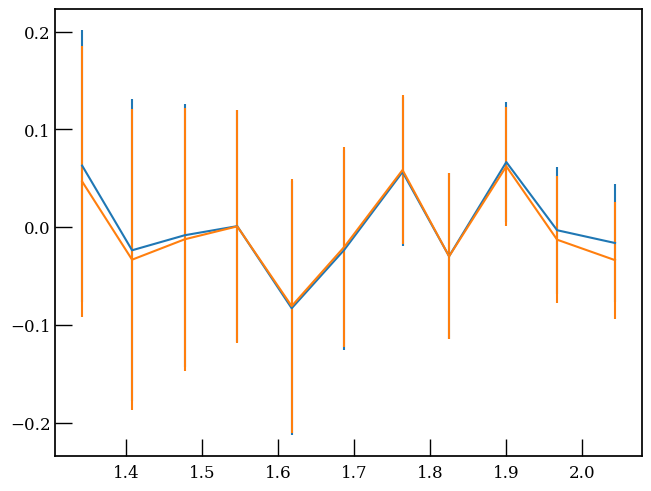

In [154]:
y_linear = slope*logx + intercept
y_quad = a*logx**2 + b*logx + c
plt.errorbar(logx, logy-y_linear, yerr = logy_std)
plt.errorbar(logx, logy-y_quad, yerr = logy_std)
plt.show()

In [155]:
print( np.sum( (y_quad-logy)**2/logy_std**2) )
print( np.sum( (y_linear-logy)**2/logy_std**2) )

2.7009214358131306
2.628083768608861


## Comparing the jackknife vs Poissonian errors. 

$ M_r < -20.99, $ $z \in [0.10,0.33)$
$ M_r < -21.5, $ $z \in [0.33,0.40)$


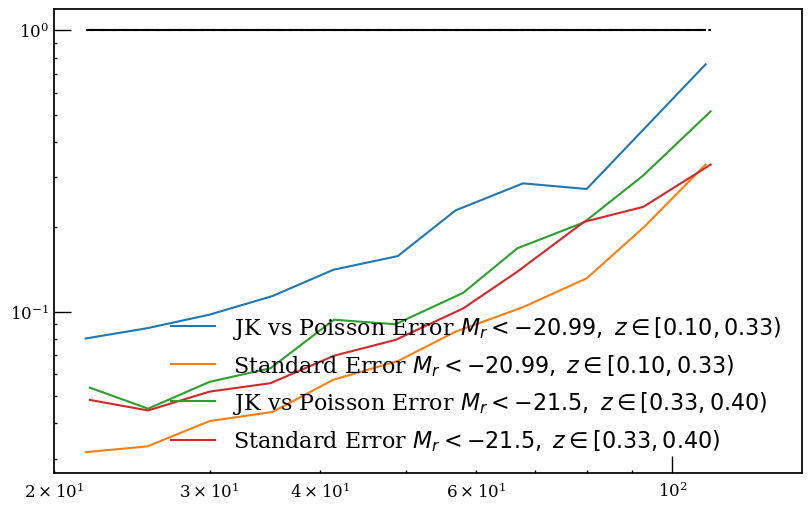

In [145]:
from scipy import stats
fig, ax = plt.subplots(figsize=(8,5))
xlow = 20; xhigh = 140
xline = np.linspace(xlow, xhigh,1000)
cmap = plt.get_cmap('Set2')
color_ind = 0
fontsize=16

for key, val in combinedDict.items():
    print(key)
    cutTable = bgs_matched[val]
    numTotal = len(cutTable)
    numCluster = len(np.unique(cutTable['ID']))

    lambda_true_list = []
    lambda_rm_list = []
    lambda_rm_stddev_list = []
    lambda_true_stddev_list = []
    lambda_rm_sem_list = []
    lambda_true_sem_list = []
    lambda_true_err_jk_list = []
    for i, lmda_bin in enumerate(lmda_bins):
        cut = (cutTable['LAMBDA'] >= lmda_bin[0]) & (cutTable['LAMBDA'] < lmda_bin[1])
            
        binnedTable = cutTable[cut]
        lambda_tot, lambda_true, lambda_true_err = calc_specRichness_stacked(binBoundaries, binCent, binnedTable)

        ##Stacked clusters
        numCl = len(unique(binnedTable, keys='ID'))
        lambda_rm_list = np.hstack((lambda_rm_list, np.mean(binnedTable['LAMBDA'])))  
        lambda_rm_stddev_list = np.hstack((lambda_rm_stddev_list, np.std(binnedTable['LAMBDA']))) 
        lambda_rm_sem_list = np.hstack((lambda_rm_sem_list, stats.sem(binnedTable['LAMBDA'])))  
        lambda_true_stddev_list = np.hstack((lambda_true_stddev_list, lambda_true_err))
        lambda_true_sem_list = np.hstack((lambda_true_sem_list, lambda_true_err/np.sqrt(numCl)))
        lambda_true_list = np.hstack((lambda_true_list,lambda_true))   

        ##Calculating individual richnesses and using jackknife error
        rmTable = unique(binnedTable, keys='ID')
        ID_list, lambda_tot_list_ind, lambda_true_list_ind  = calc_specRichness_individual(binBoundaries, binCent, binnedTable)
        lambda_rm = [rm_lambda for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list] 
        rm_id = [rmTable['ID'][i] for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list] 
        ind = [i for i, rm_lambda in enumerate(rmTable['LAMBDA']) if rmTable['ID'][i] in ID_list]
        lambda_tot_list_ind = np.asarray(lambda_tot_list_ind)
        lambda_true_list_ind = np.asarray(lambda_true_list_ind)
        lambda_rm_ind = np.asarray(lambda_rm)
    
        ##Filtering out the clusters with no spectrospic richness information and assigning spectroscopic information
        rmTable = rmTable[ind]
        rmTable['lambda_true'] = lambda_true_list_ind
        rmTable['lambda_tot'] = lambda_tot_list_ind
        lambda_true_err_jk, bias, std_err, _ = jk_stats(rmTable['lambda_true'], sem, confidence_level=0.68)
        lambda_true_err_jk_list = np.hstack((lambda_true_err_jk_list, lambda_true_err_jk))

        ##Linear fitting
        bcesMethod=0
        ##Use the standard error for errors on the coefficients. 
        slope, intercept, slope_err, intercept_err, covab = linear_fit(lambda_rm_list, lambda_true_list, lambda_rm_sem_list, lambda_true_sem_list, bcesMethod=bcesMethod)

        ##Use the standard error of the regression (approx. standard deviation) for goodness of fit.
        chi_squared, degrees_of_freedom, p_value = compute_chisq(lambda_rm_list, lambda_true_list, lambda_rm_stddev_list, lambda_true_stddev_list, slope, intercept, \
                                                             cov=False, verbose=False)
        best_fit_label = r'$\log(y)={:.2f}(\pm {:.2f})\log(x) {:+.2f}(\pm {:.2f}), p={:.3f}$'.format(slope, slope_err, intercept, intercept_err, p_value)
        label = key + ', ' + r'$N={:d}$'.format(numCluster) + r', $n={:d}$'.format(numTotal) + ', ' + best_fit_label

        ##Set pivot point to 60
        bias = np.log10(60)*(1-slope)-intercept

        
    ax.plot(lambda_rm_list, lambda_true_err_jk_list/lambda_true_stddev_list, label='JK vs Poisson Error '+key)
    ax.plot(lambda_rm_list, lambda_true_sem_list/lambda_true_stddev_list, label='Standard Error '+key)
    ax.plot(lambda_rm_list, np.ones_like(lambda_rm_list), linestyle='dashed', color='black')
    #ax.errorbar(lambda_rm_list*1.02, np.zeros_like(lambda_rm_list), yerr=lambda_true_stddev_list, label='Poisson '+key)

ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_xticks([20,30,50,70,100,150])
ax.set_xscale('log'); 
ax.set_yscale('log')
ax.set_xlim([xlow, xhigh]); 
plt.legend(frameon=False, loc='best', fontsize=fontsize)
#plt.savefig('plots/lambda_spec_lambda_rm_binned_lmda_gtr20_bivariate_jackkknife_error.jpeg')
plt.show()